# Forecasting Power Generation in a Combined-Cycle Thermal Power Plant

## Using Multiple Linear Regression with Environmental Sensors for Energy Dispatch Optimization

#### Author 1
- **Name:** João Pedro Fernandes de Aquino
- **GitHub:** https://github.com/Joaof14

#### Author 2
- **Name:** Anderson Carlos da Silva Morais
- **GitHub:** https://github.com/AndersonCSM

## Project Summary

A combined-cycle thermal power plant (CCPP) is a highly efficient facility that combines gas and steam turbines to generate electricity. It reuses the heat from the gas turbine exhaust (Brayton cycle) to produce steam in a boiler, driving a second turbine (Rankine cycle) and significantly increasing efficiency, which can reach up to 60% while reducing greenhouse gas emissions.

However, the main technical challenge lies in the integration, synchronization, and joint operation of the two distinct thermodynamic cycles, making the net electrical power output (PE) highly sensitive to environmental conditions.

Given this, the goal of this project is to build a mathematical model based on **multiple linear regression** to predict power generation from environmental sensors, enabling better energy dispatch optimization for the plant.

[Kaggle Project](https://www.kaggle.com/datasets/rinichristy/combined-cycle-power-plant-data-set-uci-data)


## Project Steps
1. Data exploration and quality checks;
2. Validate modeling assumptions;
3. Feature selection;
4. Normalization or scaling;
5. Data split;
6. Model fitting (adjustment);
7. Assessment;
8. Coefficient or feature-importance analysis;
9. Residual/error analysis;
10. Report.

## 1. Data Exploration

This UCI dataset contains 9,568 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the plant was operating at full load. The features are:
- hourly average ambient Temperature (T)
- Ambient Pressure (AP), measured in mbar
- Relative Humidity (RH), measured in percentage
- Exhaust Vacuum (V), measured in cm Hg and related to steam turbine pressure
- the net hourly electrical energy output (PE) of the plant, measured in MW (megawatts)

Steps:

1. **Initial Inspection**
   * `df.info()`: check the number of rows and columns, and the data types (int, float, object).
   * `df.describe()`: obtain a quick statistical summary (mean, standard deviation, minimum, maximum, and quartiles).

2. **Data Quality Validation**
   * **Missing Values:** check whether missing data exist (`df.isnull().sum()`) and define a strategy (remove or fill).
   * **Duplicate Data:** identify and remove identical readings that may distort the analysis (`df.duplicated().sum()`).

3. **Univariate Analysis**
   * **Distribution:** plot histograms to understand how each sensor's data is distributed.
   * **Outlier Detection:** use boxplots to identify extreme values that deviate from the expected plant pattern.

4. **Bivariate and Multivariate Analysis**
   * **Correlation Matrix:** compute indices such as Pearson's correlation to quantify the strength of the relationship between variables (for example, pressure vs. generated energy).
   * **Visual Trends:** create scatter plots crossing the predictor variables with the target variable to validate hypotheses visually.

5. **Preparation and Transformation (Feature Engineering)**
   * **Scaling:** apply transformations such as `StandardScaler` or `MinMaxScaler` to ensure that all variables are on the same proportional scale, avoiding bias during model training.

In [1]:
# python libraries imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import RidgeCV  # RidgeCV já utiliza a validação cruzada
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_absolute_error

In [3]:
!pip install kagglehub

In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

In [5]:
# Nome do arquivo
file_path = "Power Plant Data.csv"

# Carrega a versão mais recente do dataset como um DataFrame Pandas
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS, "rinichristy/combined-cycle-power-plant-data-set-uci-data", file_path
)

df.head()

100%|██████████| 311k/311k [00:00<00:00, 1.48MB/s]


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### 1.1. Initial Inspection

In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


### 1.2. Data Quality Validation

In [7]:
# 1.2.2
# Existem linhas duplicadas, contudo isso não é garantia de erro na coleta de dados
df.duplicated().sum()

np.int64(41)

/tmp/ipykernel_5299/3091144358.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grupos_iguais = todas_duplicadas.groupby(list(df.columns)).apply(lambda x: list(x.index))


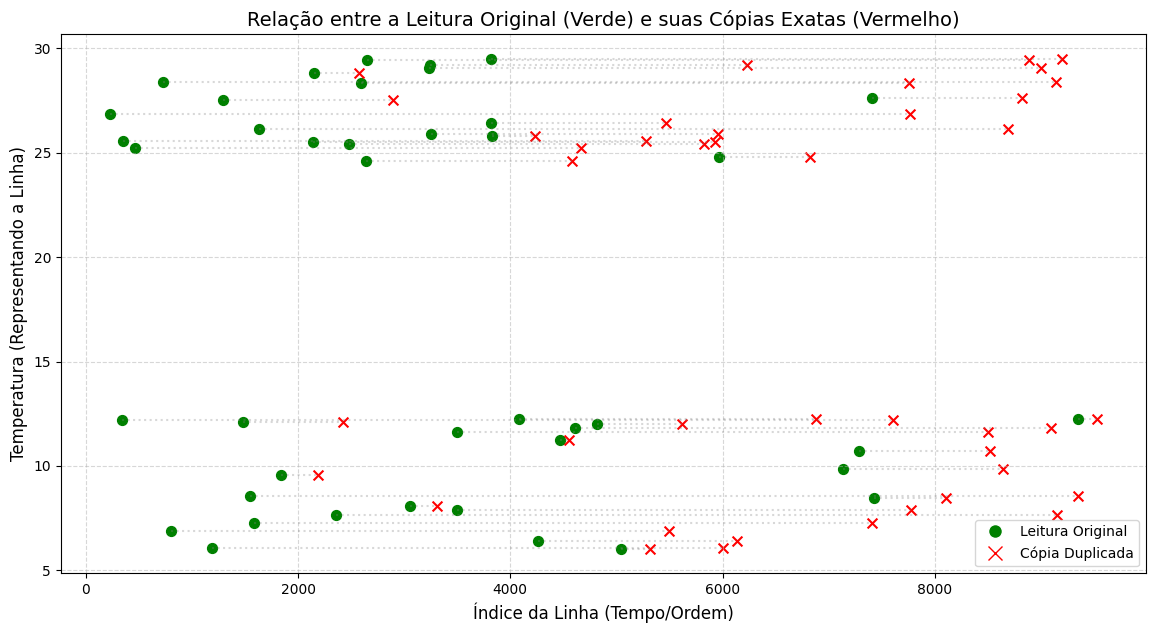

In [8]:
# 1.2.2.1. Todas as linhas que têm cópias (o keep=False traz originais e cópias)
todas_duplicadas = df[df.duplicated(keep=False)]

# 1.2.2.2. Agrupando as linhas que são exatamente iguais e pegar seus índices
# Isso criará uma lista de índices para cada grupo de linhas idênticas
grupos_iguais = todas_duplicadas.groupby(list(df.columns)).apply(lambda x: list(x.index))

plt.figure(figsize=(14, 7))

# 1.2.2.3. Iterando sobre cada grupo de linhas iguais
for índices in grupos_iguais:
    if len(índices) >= 2:
        # A primeira ocorrência (o "original")
        indice_original = índices[0]
        # As ocorrências seguintes (as "cópias")
        indices_copias = índices[1:]

        # Plotando um ponto verde para a leitura "original"
        plt.scatter(indice_original, df.loc[indice_original, "AT"], color="green", marker="o", s=50)

        # Plotando pontos vermelhos para as "cópias"
        plt.scatter(indices_copias, [df.loc[i, "AT"] for i in indices_copias], color="red", marker="x", s=50)

        # Opcional: Desenhamos uma linha cinza ligando o original às suas cópias para evidenciar a distância entre elas
        for copia in indices_copias:
            plt.plot(
                [indice_original, copia],
                [df.loc[indice_original, "AT"], df.loc[copia, "AT"]],
                color="gray",
                alpha=0.3,
                linestyle=":",
            )

# 1.2.2.4. Ajustes do gráfico
plt.title("Relação entre a Leitura Original (Verde) e suas Cópias Exatas (Vermelho)", fontsize=14)
plt.xlabel("Índice da Linha (Tempo/Ordem)", fontsize=12)
plt.ylabel("Temperatura (Representando a Linha)", fontsize=12)

# Criando legendas manuais
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker="o", color="w", label="Leitura Original", markerfacecolor="green", markersize=10),
    Line2D([0], [0], marker="x", color="red", label="Cópia Duplicada", markersize=10, linestyle="None"),
]
plt.legend(handles=legend_elements)

plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

The spacing between readings indicates that there are no duplicated readings, meaning that no sensor recorded the same value twice.

### 1.3. Univariate Analysis

In [9]:
# 1.2.1.
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


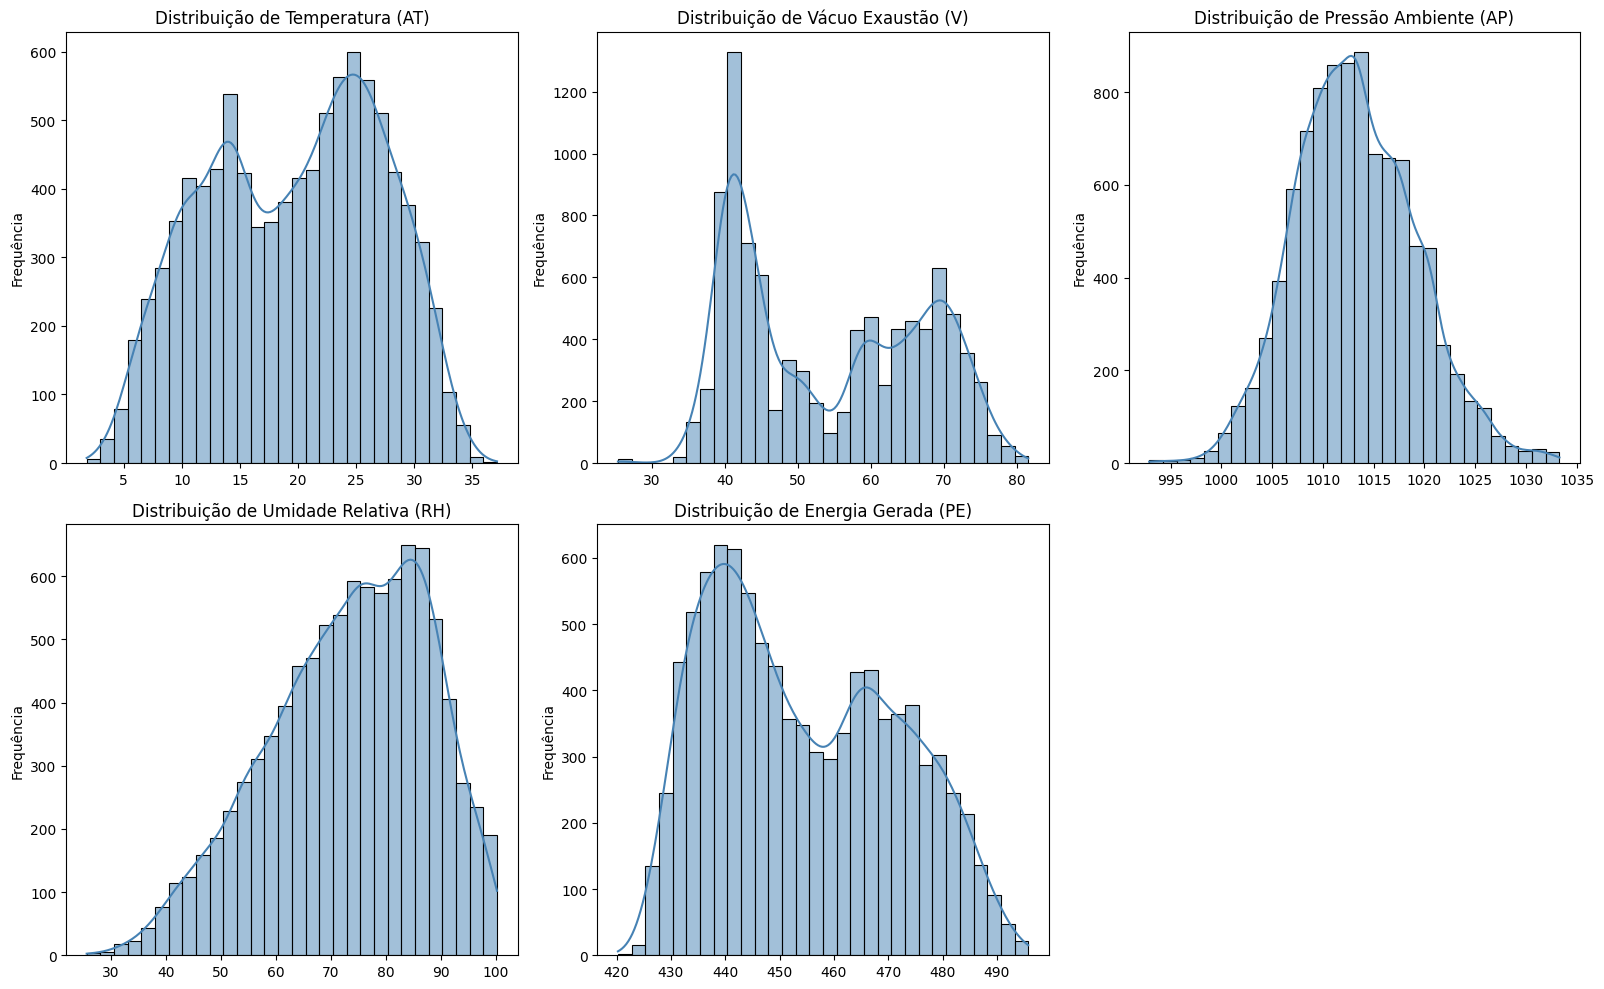

In [10]:
# Step 1.3.1
# Definindo as colunas e os títulos para deixar os gráficos autoexplicativos
colunas = ["AT", "V", "AP", "RH", "PE"]
titulos = [
    "Temperatura (AT)",
    "Vácuo Exaustão (V)",
    "Pressão Ambiente (AP)",
    "Umidade Relativa (RH)",
    "Energia Gerada (PE)",
]

# Cria um painel com 2 linhas e 3 colunas de gráficos
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()  # Achata a matriz de eixos para facilitar o loop

# Loop para desenhar cada histograma
for i, col in enumerate(colunas):
    # O kde=True desenha a linha de densidade por cima das barras
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue", bins=30)
    axes[i].set_title(f"Distribuição de {titulos[i]}", fontsize=12)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequência")

# Apaga o 6º gráfico (vazio), já que temos apenas 5 variáveis
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

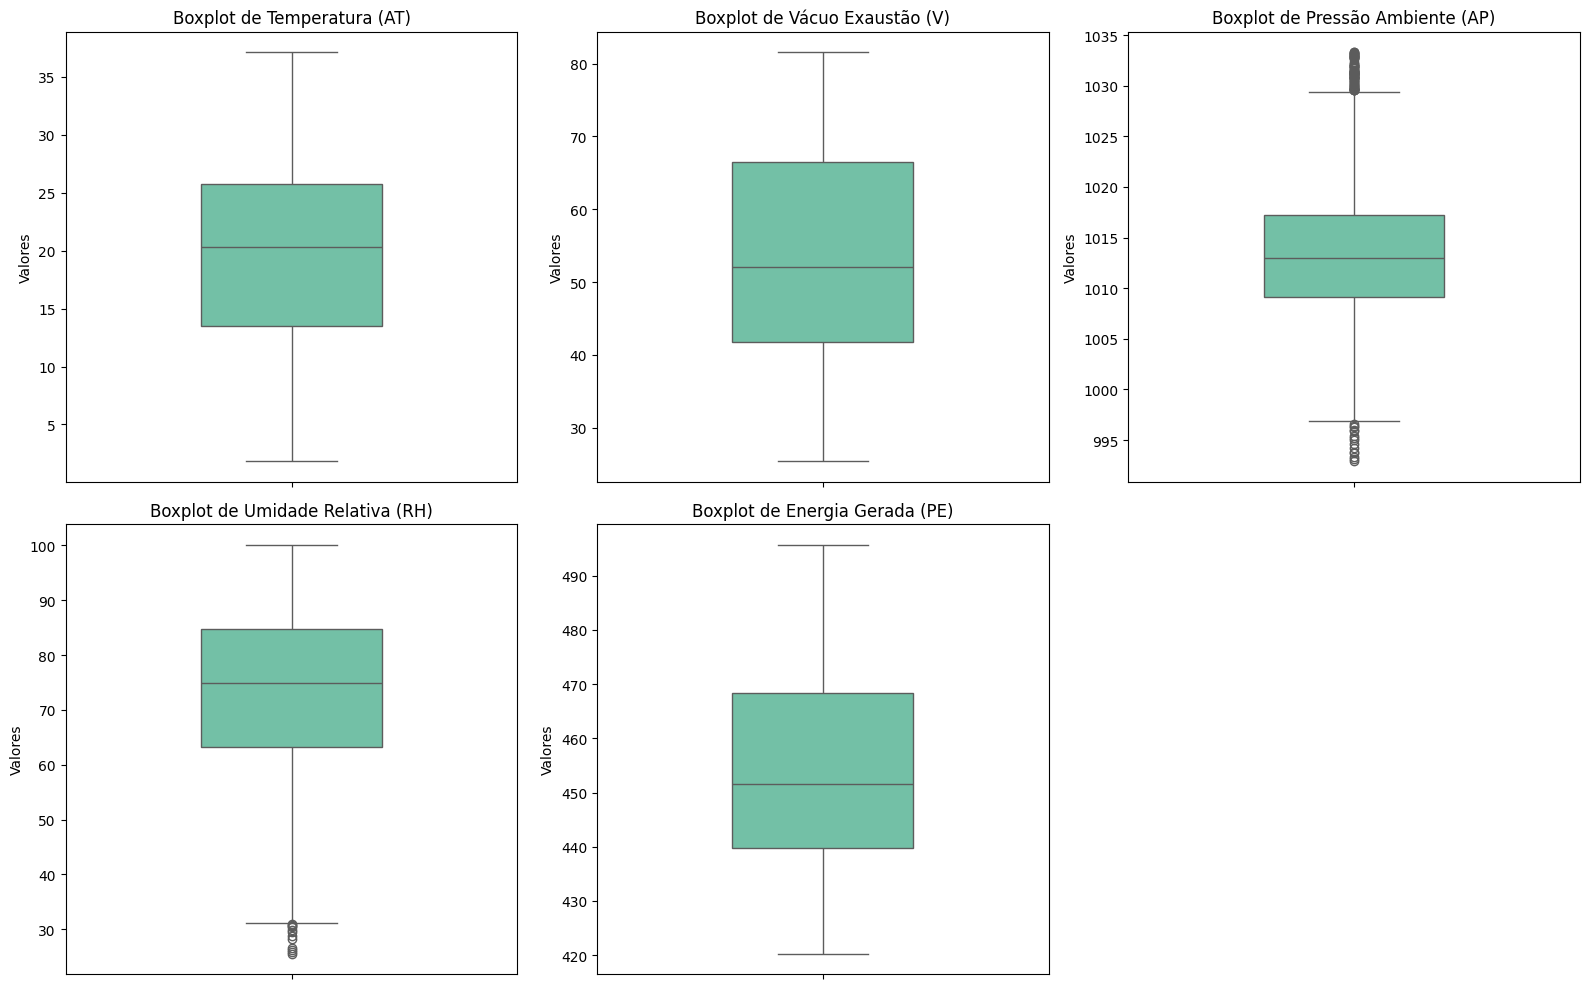

In [11]:
# Step 1.3.2
# Cria um novo painel para os Boxplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

# Loop para desenhar cada boxplot
for i, col in enumerate(colunas):
    # O orient='v' deixa a caixa na vertical
    sns.boxplot(y=df[col], ax=axes[i], color="mediumaquamarine", width=0.4)
    axes[i].set_title(f"Boxplot de {titulos[i]}", fontsize=12)
    axes[i].set_ylabel("Valores")

# Apaga o 6º gráfico (vazio)
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [12]:
for i, col in enumerate(colunas):
    print(f"min {col}: {df[col].min()}")
    print(f"max {col}: {df[col].max()}")
    print("")

min AT: 1.81
max AT: 37.11

min V: 25.36
max V: 81.56

min AP: 992.89
max AP: 1033.3

min RH: 25.56
max RH: 100.16

min PE: 420.26
max PE: 495.76



In [13]:
# A humidade relativa possui mínima de 0 e máxima de 100 (água)

# Impondo um valor máximo de 100.0 para a coluna RH
# Valores menores que 100.0 não serão afetados
df_2 = df.copy()
df_2["RH"] = df["RH"].clip(upper=100.0)

# Verificação
print("Novo valor máximo de RH:", df_2["RH"].max())

Novo valor máximo de RH: 100.0


### 1.4. Bivariate and Multivariate Analysis

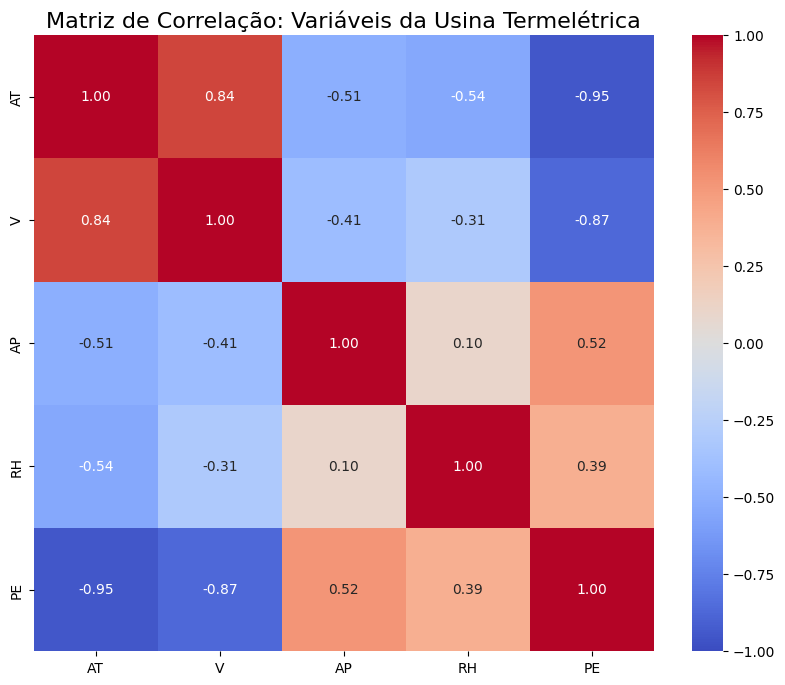

In [14]:
# Step 1.4.1 Qual sensor afeta mais a geração de energia (PE)?

# 1.4.1.1. Calcula a matriz de correlação (o padrão já é o método de Pearson)
matriz_correlacao = df_2.corr()

# 1.4.1.2. Configura o tamanho da tela
plt.figure(figsize=(10, 8))

# 1.4.1.3. Plota o Mapa de Calor
# annot=True: Mostra os números dentro dos quadrados
# cmap: Paleta de cores (coolwarm vai do azul pro vermelho)
# vmin e vmax: Força a escala das cores ir de -1 até 1
sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

# 1.4.1.4. Título
plt.title("Matriz de Correlação: Variáveis da Usina Termelétrica", fontsize=16)
plt.show()

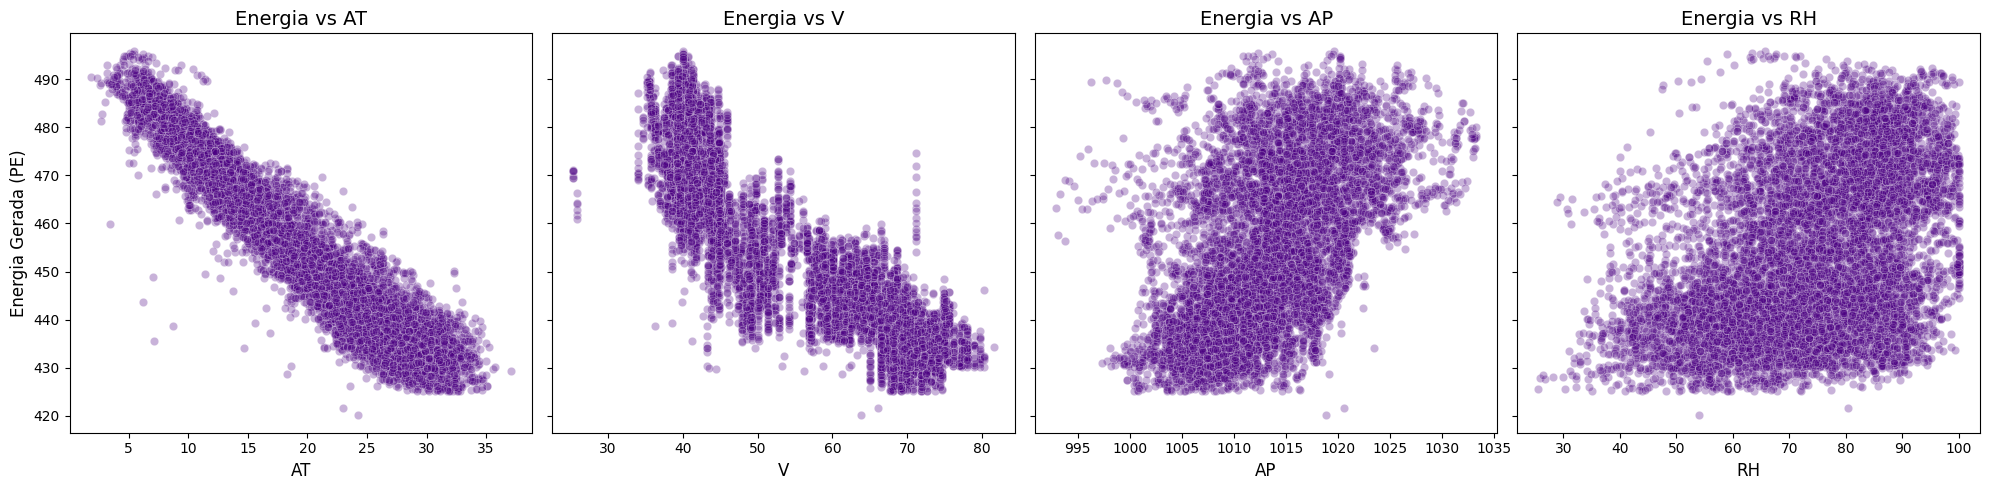

In [15]:
# Step 1.4.2
# Cria uma grade de gráficos com 1 linha e 4 colunas
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

# Lista com as nossas variáveis preditoras (os sensores)
preditores = ["AT", "V", "AP", "RH"]

# Loop para plotar cada sensor contra a Energia (PE)
for i, col in enumerate(preditores):
    # O alpha=0.3 deixa os pontos transparentes para vermos onde há maior concentração
    sns.scatterplot(x=df_2[col], y=df_2["PE"], ax=axes[i], alpha=0.3, color="indigo")
    axes[i].set_title(f"Energia vs {col}", fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)

axes[0].set_ylabel("Energia Gerada (PE)", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Validate Modeling Assumptions

- Os gráficos de dispersão entre cada variável preditora (AT, V, AP, RH) e a variável resposta (PE) revelam **relações aproximadamente lineares** em todos os casos. Não foram observadas curvaturas acentuadas que sugerissem a necessidade de transformações não lineares. Portanto, a premissa de linearidade é considerada atendida para este conjunto de dados.

- A matriz de correlação de Pearson em ***1.4*** (também exibida na análise exploratória) mostra que a maior correlação entre variáveis independentes ocorre entre **AT e V** (r = 0.84). Valores de correlação superiores a **0.85** costumam indicar multicolinearidade problemática. Como nenhum par ultrapassa esse limite, e o modelo será regularizado com **Ridge/Lasso** (que mitiga efeitos de multicolinearidade), consideramos que a premissa está adequadamente endereçada.

## 3. Feature Selection

In [16]:
# Separando quem são as 'Features' (Sensores) e quem é o 'Target' (Energia)
X = df_2[["AT", "V", "AP", "RH"]]  # Variáveis que vão prever
y = df_2["PE"]  # Variável que queremos descobrir

## 4. Normalization or scaling
- **MinMaxScaler:** Espreme todos os dados entre 0 e 1. Problema: Se você tem um outlier muito alto, ele esmaga todos os dados normais para perto do zero. Não é ideal para a nossa usina.
- **StandardScaler:** Usa a média para centralizar os dados. Problema: A média é facilmente "puxada" e distorcida pelos outliers.
- **RobustScaler:** A solução de ouro. Ele ignora os extremos (outliers) e usa a mediana e os quartis (o "meio" da caixa do seu Boxplot) para nivelar os dados.

### 4.1. Scaling Comparison

In [17]:
# Separando os dados antes de transformar (Regra de Ouro)
# 80% para treino, 20% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scalers = {"RobustScaler": RobustScaler(), "StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler()}

resultados_scalers = []

for nome, scaler in scalers.items():
    # Escalona
    X_train_scl = scaler.fit_transform(X_train)
    X_test_scl = scaler.transform(X_test)

    # RidgeCV
    ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5, scoring="neg_mean_squared_error")
    ridge.fit(X_train_scl, y_train)
    y_pred = ridge.predict(X_test_scl)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    resultados_scalers.append({"Scaler": nome, "R2": r2, "RMSE": rmse, "MAE:": mae})

df_scalers = pd.DataFrame(resultados_scalers)
print(df_scalers)

           Scaler        R2      RMSE      MAE:
0    RobustScaler  0.930107  4.502553  3.595889
1  StandardScaler  0.930107  4.502562  3.595888
2    MinMaxScaler  0.930107  4.502567  3.595888


**Observações:**
A escolha do método de normalização não afetou significativamente o desempenho preditivo do modelo Ridge. Portanto, mantivemos o RobustScaler por sua robustez teórica a outliers e pela consistência com as etapas anteriores do projeto.

### 4.2. Data Scaling

In [18]:
# Inicializando o transformador escolhido
scaler = RobustScaler()

# Escalonamento
# fit_transform: O modelo 'aprende' a escala com os dados de treino e já os transforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: Aplicamos a MESMA escala descoberta acima nos dados de teste (sem aprender nada novo)
X_test_scaled = scaler.transform(X_test)

# Convertendo de volta para um formato de tabela (DataFrame) só para podermos visualizar como ficou
df_X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Dados antes do Escalonamento (Valores brutos):")
print(X_train.head())
print("\n--------------------------------------------------\n")
print("Dados APÓS o Escalonamento (Prontos para a IA):")
print(df_X_train_scaled.head().round(3))  # Arredondado para 3 casas decimais

Dados antes do Escalonamento (Valores brutos):
         AT      V       AP     RH
5487  21.92  49.02  1009.29  88.56
3522  11.09  40.43  1025.47  74.97
6916   8.49  39.61  1021.05  87.74
7544  11.43  44.78  1013.43  82.45
7600  17.28  39.99  1007.09  74.25

--------------------------------------------------

Dados APÓS o Escalonamento (Prontos para a IA):
      AT      V     AP     RH
0  0.129 -0.122 -0.452  0.630
1 -0.762 -0.468  1.524 -0.002
2 -0.976 -0.501  0.984  0.592
3 -0.734 -0.293  0.054  0.346
4 -0.253 -0.486 -0.721 -0.035


#### Lasso Validation

In [19]:
from sklearn.linear_model import LassoCV

# Usando os dados já escalonados (RobustScaler) e split 80/20 como base inicial
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

# Coeficientes
coef_lasso = pd.Series(lasso_cv.coef_, index=X.columns)
print("Coeficientes Lasso:")
print(coef_lasso.round(4))

Coeficientes Lasso:
AT   -24.1329
V     -5.7507
AP     0.5077
RH    -3.4008
dtype: float64


**Observations:**
Lasso manteve todas as quatro variáveis selecionadas anteriormente, isso indica que todas contribuem significativamente para a previsão da energia, mesmo controlando umas pelas outras.
A matriz de correlação mostrava que AT e V são altamente correlacionadas (0.84), mas o Lasso não zerou V. Embora correlacionadas, cada uma carrega uma informação adicional sobre o processo físico. O Lasso considerou que remover V pioraria a previsão, então manteve ambas, mesmo que com coeficiente reduzido em relação a uma regressão sem regularização.

## 5.  Data Split

In [20]:
# TO-DO: fazer conjuntos diferentes para treinamento, seria cross validation?
from sklearn.model_selection import train_test_split

proporcoes = [0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
resultados_split = []

# Usando o melhor scaler
scaler = RobustScaler()

for test_size in proporcoes:
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=test_size, random_state=42)

    X_tr_scl = scaler.fit_transform(X_tr)
    X_te_scl = scaler.transform(X_te)

    ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
    ridge.fit(X_tr_scl, y_tr)
    y_pred = ridge.predict(X_te_scl)

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    resultados_split.append(
        {"Test Size": test_size, "Treino %": (1 - test_size) * 100, "R2": r2, "RMSE": rmse, "MAE:": mae}
    )

df_split = pd.DataFrame(resultados_split)
print(df_split)

   Test Size  Treino %        R2      RMSE      MAE:
0       0.30      70.0  0.927557  4.608403  3.649867
1       0.25      75.0  0.929199  4.536572  3.585750
2       0.20      80.0  0.930107  4.502553  3.595889
3       0.15      85.0  0.928339  4.464217  3.565791
4       0.10      90.0  0.933302  4.360279  3.550190
5       0.05      95.0  0.929460  4.387192  3.581935


**Observations:**
- Ao reduzir o tamanho do conjunto de teste de 30% para 10%, o modelo recebe mais dados para treino (de 70% para 90%), e isso melhora levemente as métricas: o RMSE cai de aproximadamente 4.61 para 4.36 MW, e o MAE cai de aproximadamente 3.65 para 3.55 MW.
- O melhor resultado numérico apareceu com 10% de teste (R² ≈ 0.933, RMSE ≈ 4.36, MAE ≈ 3.55), indicando que o modelo aproveita bem mais dados de treino.
- Quando o teste cai para 5%, o desempenho piora um pouco (R² e erros), mesmo com mais treino. Isso acontece porque um teste muito pequeno aumenta a instabilidade da avaliação: a métrica passa a depender mais do acaso da amostra.
- As diferenças entre cenários são pequenas (ordem de décimos de MW), o que sugere que o modelo é robusto à escolha da proporção de split.
- Por critério metodológico, manter 80/20 é uma escolha equilibrada: preserva boa quantidade de treino e, ao mesmo tempo, mantém um conjunto de teste suficientemente representativo para avaliação confiável.

**Resumo interpretativo:**

- 10% teste deu o melhor número.
- 80/20 continua sendo a melhor escolha prática para relatório técnico, comparabilidade e estabilidade de avaliação.

## 6. Model Fitting (Adjustment)

Com base nas análises anteriores, definimos a configuração final:
- **Escalonador**: RobustScaler (mais robusto a outliers).
- **Divisão Treino/Teste**: 80% / 20%.

Treinamos dois modelos regularizados:
- **Ridge (L2)** : penaliza a soma dos quadrados dos coeficientes.
- **Lasso (L1)** : penaliza a soma dos valores absolutos, podendo zerar coeficientes.

Ambos utilizam validação cruzada interna de 5 folds para escolha automática do hiperparâmetro `alpha`.  


In [21]:
# Divisão dos dados de acordo com o padrão ouro
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling dos dados a partir do escalonador de melhor desempenho
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge final
ridge_final = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_final.fit(X_train_scaled, y_train)

# Lasso final
lasso_final = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=10000, random_state=42)
lasso_final.fit(X_train_scaled, y_train)

print(f"Melhor alpha Ridge: {ridge_final.alpha_:.4f}")
print(f"Melhor alpha Lasso: {lasso_final.alpha_:.4f}")

Melhor alpha Ridge: 0.3054
Melhor alpha Lasso: 0.0010


## 7. Assessment

In [22]:
def avaliar_modelo(modelo, X_teste, y_teste, nome):
    y_pred = modelo.predict(X_teste)
    r2 = r2_score(y_teste, y_pred)
    rmse = np.sqrt(mean_squared_error(y_teste, y_pred))
    mae = mean_absolute_error(y_teste, y_pred)
    print(f"{nome}:")
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.2f} MW")
    print(f"  MAE: {mae:.2f} MW\n")
    return {"Modelo": nome, "R2": r2, "RMSE": rmse, "MAE": mae}


resultados_finais = []
resultados_finais.append(avaliar_modelo(ridge_final, X_test_scaled, y_test, "Ridge"))
resultados_finais.append(avaliar_modelo(lasso_final, X_test_scaled, y_test, "Lasso"))

df_resultados = pd.DataFrame(resultados_finais)

Ridge:
  R²: 0.9301
  RMSE: 4.50 MW
  MAE: 3.60 MW

Lasso:
  R²: 0.9301
  RMSE: 4.50 MW
  MAE: 3.60 MW



**Observations:**
Ambos os modelos apresentaram desempenho virtualmente idêntico no conjunto de teste (R² = 0,9301; RMSE = 4,50 MW; MAE = 3,60 MW).  
Diante da equivalência das métricas, optou-se pelo **Ridge** como modelo final.

## 8. Coefficient or Feature-Importance Analysis

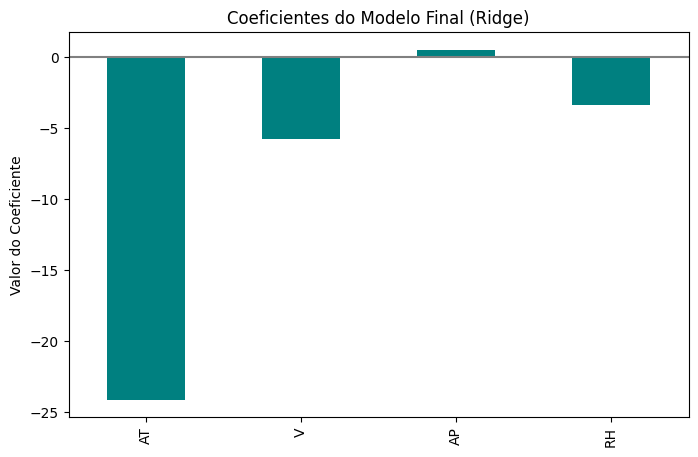

Coeficientes:
AT   -24.1157
V     -5.7671
AP     0.5119
RH    -3.3986
dtype: float64


In [23]:
# Escolha o melhor modelo (ex.: ridge_final)
modelo_escolhido = ridge_final
coeficientes = pd.Series(modelo_escolhido.coef_, index=X.columns)

plt.figure(figsize=(8, 5))
coeficientes.plot(kind="bar", color="teal")
plt.title("Coeficientes do Modelo Final (Ridge)")
plt.ylabel("Valor do Coeficiente")
plt.axhline(y=0, color="gray", linestyle="-")
plt.show()

print("Coeficientes:")
print(coeficientes.round(4))

## 9. Residual/Error Analysis

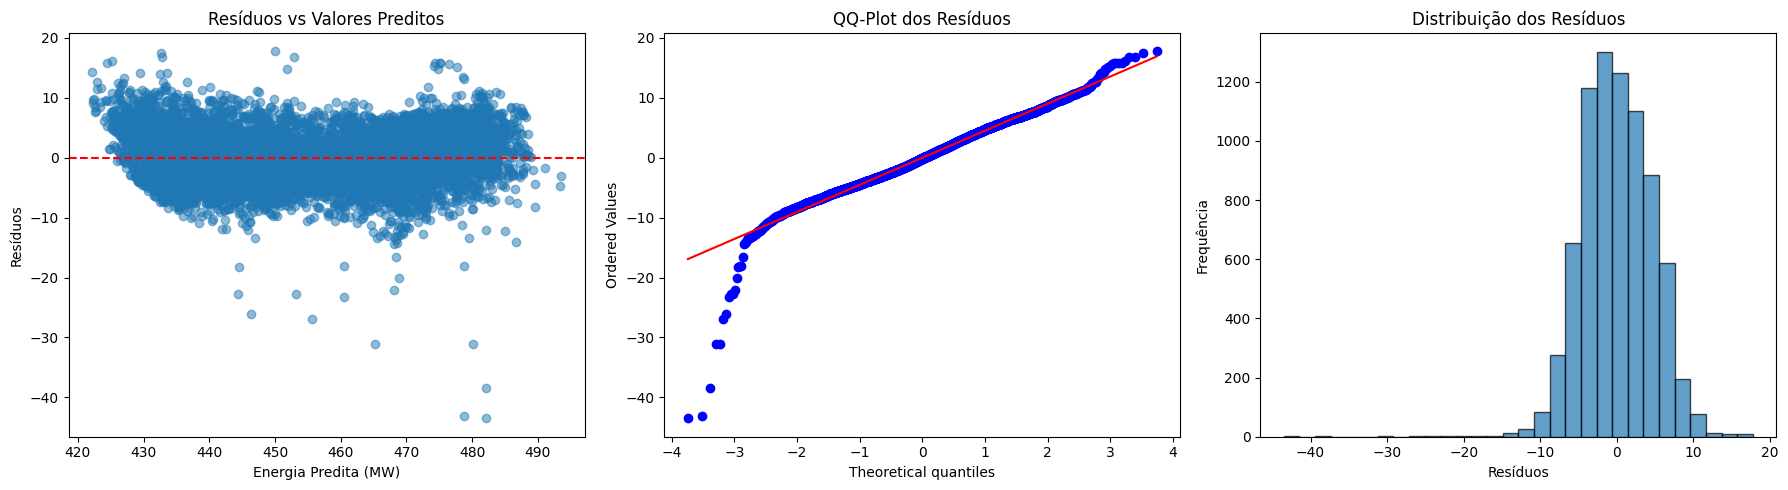

In [24]:
# Usar o modelo escolhido
y_pred_train = modelo_escolhido.predict(X_train_scaled)
residuos = y_train - y_pred_train

# 1. Resíduos vs Preditos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_train, residuos, alpha=0.5)
axes[0].axhline(y=0, color="r", linestyle="--")
axes[0].set_xlabel("Energia Predita (MW)")
axes[0].set_ylabel("Resíduos")
axes[0].set_title("Resíduos vs Valores Preditos")

# 2. QQ-plot
from scipy import stats

stats.probplot(residuos, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot dos Resíduos")

# 3. Histograma
axes[2].hist(residuos, bins=30, edgecolor="k", alpha=0.7)
axes[2].set_xlabel("Resíduos")
axes[2].set_ylabel("Frequência")
axes[2].set_title("Distribuição dos Resíduos")

plt.tight_layout()
plt.show()

***Observações***
1. **Homocedasticidade e Linearidade** (gráfico de resíduos vs preditos): os resíduos se distribuem aleatoriamente em torno de zero, sem padrões em forma de funil ou curva.
2. **Independência** (já considerada na coleta dos dados e confirmada pela ausência de padrões temporais óbvios).
3. **Normalidade** (QQ-plot e histograma): os resíduos seguem aproximadamente uma distribuição normal, especialmente importante para inferência estatística.


## 10. Report

1. Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) e a variável dependente (PE). Quais variáveis parecem ter maior influência na produção de energia?
   
   ***Resposta:*** As variáveis que apresentam maior influência na produção de energia são AT e V, ambas com correlação negativa muito forte. Isso indica que aumentos na temperatura ambiente e no vácuo de exaustão estão associados a quedas significativas na potência elétrica gerada.

2. Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) entre si. Existe alguma relação forte entre elas? Se sim, isso pode indicar multicolinearidade.
   
   ***Resposta:*** Existe uma correlação forte entre AT e V, contudo não fortemente suficiente para ser identificada como multicolinearidade (>= 0.85). Para evitar possíveis instabilidades nos coeficientes, optou-se pelo uso de regularização Ridge durante o desenvolvimento do modelo.

3. Construa um modelo de regressão linear múltipla utilizando as variáveis independentes (AT, V, AP, RH) para prever a variável dependente (PE). Divida os dados em treino (80%) e teste (20%).
   
   ***Resposta:*** Item ***2.4***.

4. Avalie o desempenho do modelo utilizando métricas como R², RMSE e MAE. O modelo é adequado para prever a produção de energia? Justifique sua resposta.
   
   ***Resposta:*** Sim. O modelo apresente R² = 0,93, ou seja, explica 93% da variação da energia gerada, um ajuste excelente para dados reais. Além disso, o modelo apresentou um MAE de 3,6 MW, que é um desvio inferior a 5% da faixa operacional da usina (420–495 MW), demonstrando precisão aceitável para despacho energético. Por fim o modelo se confirmou estável, uma vez que a análise de resíduos confirma homocedasticidade e normalidade, assegurando previsões confiáveis.



## Suggestions for Future Improvements

- Add a fully bilingual version (Portuguese/English) for all markdown sections and figure titles.
- Build a reproducible preprocessing pipeline with `Pipeline`/`ColumnTransformer` to avoid leakage and simplify reuse.
- Add robust outlier strategy experiments (IQR filtering, winsorization, and robust regressors) and compare impact on RMSE/MAE.
- Expand model benchmarking beyond Ridge/Lasso (e.g., ElasticNet, Random Forest Regressor, XGBoost) using the same evaluation protocol.
- Replace the single train/test split with repeated cross-validation for more stable performance estimates.
- Add uncertainty analysis (prediction intervals or bootstrap confidence intervals) for operational decision support.
- Include feature importance explainability with SHAP or permutation importance to improve interpretability for stakeholders.
- Introduce residual diagnostics tests (Breusch-Pagan, Durbin-Watson, normality tests) in addition to visual plots.
- Create a compact final metrics table with baseline vs final model, including percentage error and business-oriented interpretation.
- Package the project as a reproducible report/notebook pipeline (requirements, random seeds, and run order checklist).